In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from optbinning import OptimalBinning

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# load data
fraud_df = pd.read_csv('../data/creditcard.csv')

# recreate engineered columns from previous notebooks
fraud_df['Amount_log'] = np.log1p(fraud_df['Amount'])
fraud_df['Hour'] = (fraud_df['Time']/3600 % 24).astype(int)
fraud_df = fraud_df.sort_values('Time').reset_index(drop=True)


fraud_df['rolling_avg_amount'] = fraud_df['Amount'].rolling(window= 100, min_periods=1).mean()
fraud_df['rolling_std_amount'] = fraud_df['Amount'].rolling(window=100, min_periods=1).std()
fraud_df['rolling_fraud_density'] = fraud_df['Class'].rolling(window=100, min_periods=1).mean()*100
fraud_df['rolling_txn_count']=fraud_df['Amount'].rolling(window=100, min_periods=1).count()



print(f"Data loaded: {fraud_df.shape}")
print(f"Columns: {fraud_df.columns.tolist()}")

(CVXPY) May 11 10:07:56 AM: Encountered unexpected exception importing solver GLOP:
RuntimeError('Unrecognized new version of ortools (9.15.6755). Expected < 9.15.0. Please open a feature request on cvxpy to enable support for this version.')
(CVXPY) May 11 10:07:56 AM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Unrecognized new version of ortools (9.15.6755). Expected < 9.15.0. Please open a feature request on cvxpy to enable support for this version.')


Data loaded: (284807, 37)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class', 'Amount_log', 'Hour', 'rolling_avg_amount', 'rolling_std_amount', 'rolling_fraud_density', 'rolling_txn_count']


In [2]:
x= fraud_df['Amount'].values
y = fraud_df['Class'].values 


optb = OptimalBinning(name='Amount', dtype ='numerical', solver='cp')

optb.fit(x,y)

binning_table =optb.binning_table.build()
print(binning_table)

                    Bin   Count  Count (%)  Non-event  Event  Event rate  \
0          (-inf, 1.19)   31146      0.109      30959    187       0.006   
1          [1.19, 8.90)   54254      0.190      54197     57       0.001   
2         [8.90, 19.95)   50670      0.178      50643     27       0.001   
3        [19.95, 30.13)   25103      0.088      25097      6       0.000   
4        [30.13, 75.81)   51427      0.181      51388     39       0.001   
5        [75.81, 99.84)   14242      0.050      14225     17       0.001   
6       [99.84, 237.25)   33727      0.118      33648     79       0.002   
7         [237.25, inf)   24238      0.085      24158     80       0.003   
8               Special       0      0.000          0      0       0.000   
9               Missing       0      0.000          0      0       0.000   
Totals                   284807      1.000     284315    492       0.002   

          WoE    IV    JS  
0      -1.250 0.339 0.040  
1       0.498 0.037 0.005  
2  

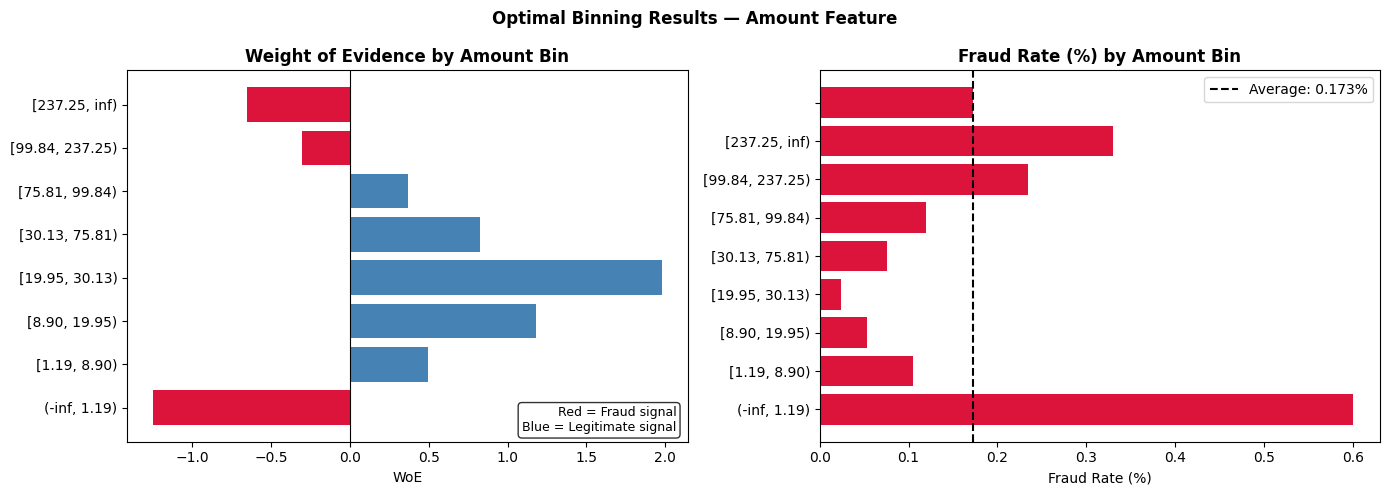

In [3]:
# visualise WoE per bin — shows fraud risk at each amount range
binning_table_clean = binning_table[~binning_table['Bin'].isin(['Special', 'Missing', 'Totals'])]


binning_table_clean=binning_table_clean.apply(lambda x: pd.to_numeric(x, errors ='ignore'))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# WoE per bin
colors = ['crimson' if x < 0 else 'steelblue' for x in binning_table_clean['WoE']]
axes[0].barh(binning_table_clean['Bin'].astype(str), 
             binning_table_clean['WoE'], color=colors)
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].set_title('Weight of Evidence by Amount Bin', fontweight='bold')
axes[0].set_xlabel('WoE')
# red = fraud concentrated, blue = legitimate concentrated
axes[0].text(0.98, 0.02, 'Red = Fraud signal\nBlue = Legitimate signal',
             transform=axes[0].transAxes, fontsize=9,
             ha='right', va='bottom',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# event rate per bin
axes[1].barh(binning_table_clean['Bin'].astype(str),
             binning_table_clean['Event rate'] * 100, color='crimson')
axes[1].axvline(x=fraud_df['Class'].mean()*100, color='black',
                linestyle='--', label=f'Average: {fraud_df["Class"].mean()*100:.3f}%')
axes[1].set_title('Fraud Rate (%) by Amount Bin', fontweight='bold')
axes[1].set_xlabel('Fraud Rate (%)')
axes[1].legend()

plt.suptitle('Optimal Binning Results — Amount Feature', fontweight='bold')
plt.tight_layout()
plt.show()

In [4]:
features =[col for col in fraud_df.columns if col != 'Class']
iv_results ={}

for feature in features:
    try:
        x=fraud_df[feature].values
        y=fraud_df['Class'].values
        optb = OptimalBinning(name=feature, dtype='numerical', solver= 'cp')
        optb.fit(x,y)


        iv = optb.binning_table.build()['IV'].iloc[-1]
        iv_results[feature] = iv
        print(f"{feature}: IV = {iv:.4f}")
    except Exception as e:
        print(f"{feature}:Error -{e}")

iv_df = pd.DataFrame.from_dict(iv_results, orient='index', columns=['IV'])
iv_df = iv_df.sort_values('IV', ascending=False)
print("\nFeature IV Rankings:")
print(iv_df)

Time: IV = 0.2743
V1: IV = 1.6470
V2: IV = 2.5920
V3: IV = 3.2386
V4: IV = 3.9551
V5: IV = 1.3794
V6: IV = 1.4993
V7: IV = 2.7769
V8: IV = 1.3279
V9: IV = 2.0344
V10: IV = 3.8128
V11: IV = 3.4096
V12: IV = 3.8872
V13: IV = 0.1271
V14: IV = 4.5064
V15: IV = 0.0708
V16: IV = 3.1581
V17: IV = 3.8027
V18: IV = 1.7156
V19: IV = 0.9675
V20: IV = 0.9608
V21: IV = 1.6758
V22: IV = 0.0852
V23: IV = 0.6517
V24: IV = 0.2426
V25: IV = 0.1740
V26: IV = 0.0868
V27: IV = 2.1269
V28: IV = 1.6441
Amount: IV = 0.8246
Amount_log: IV = 0.8246
Hour: IV = 0.2706
rolling_avg_amount: IV = 0.0464
rolling_std_amount: IV = 0.0798
rolling_fraud_density: IV = 0.0000
rolling_txn_count: IV = 0.0000

Feature IV Rankings:
                         IV
V14                   4.506
V4                    3.955
V12                   3.887
V10                   3.813
V17                   3.803
V11                   3.410
V3                    3.239
V16                   3.158
V7                    2.777
V2                   

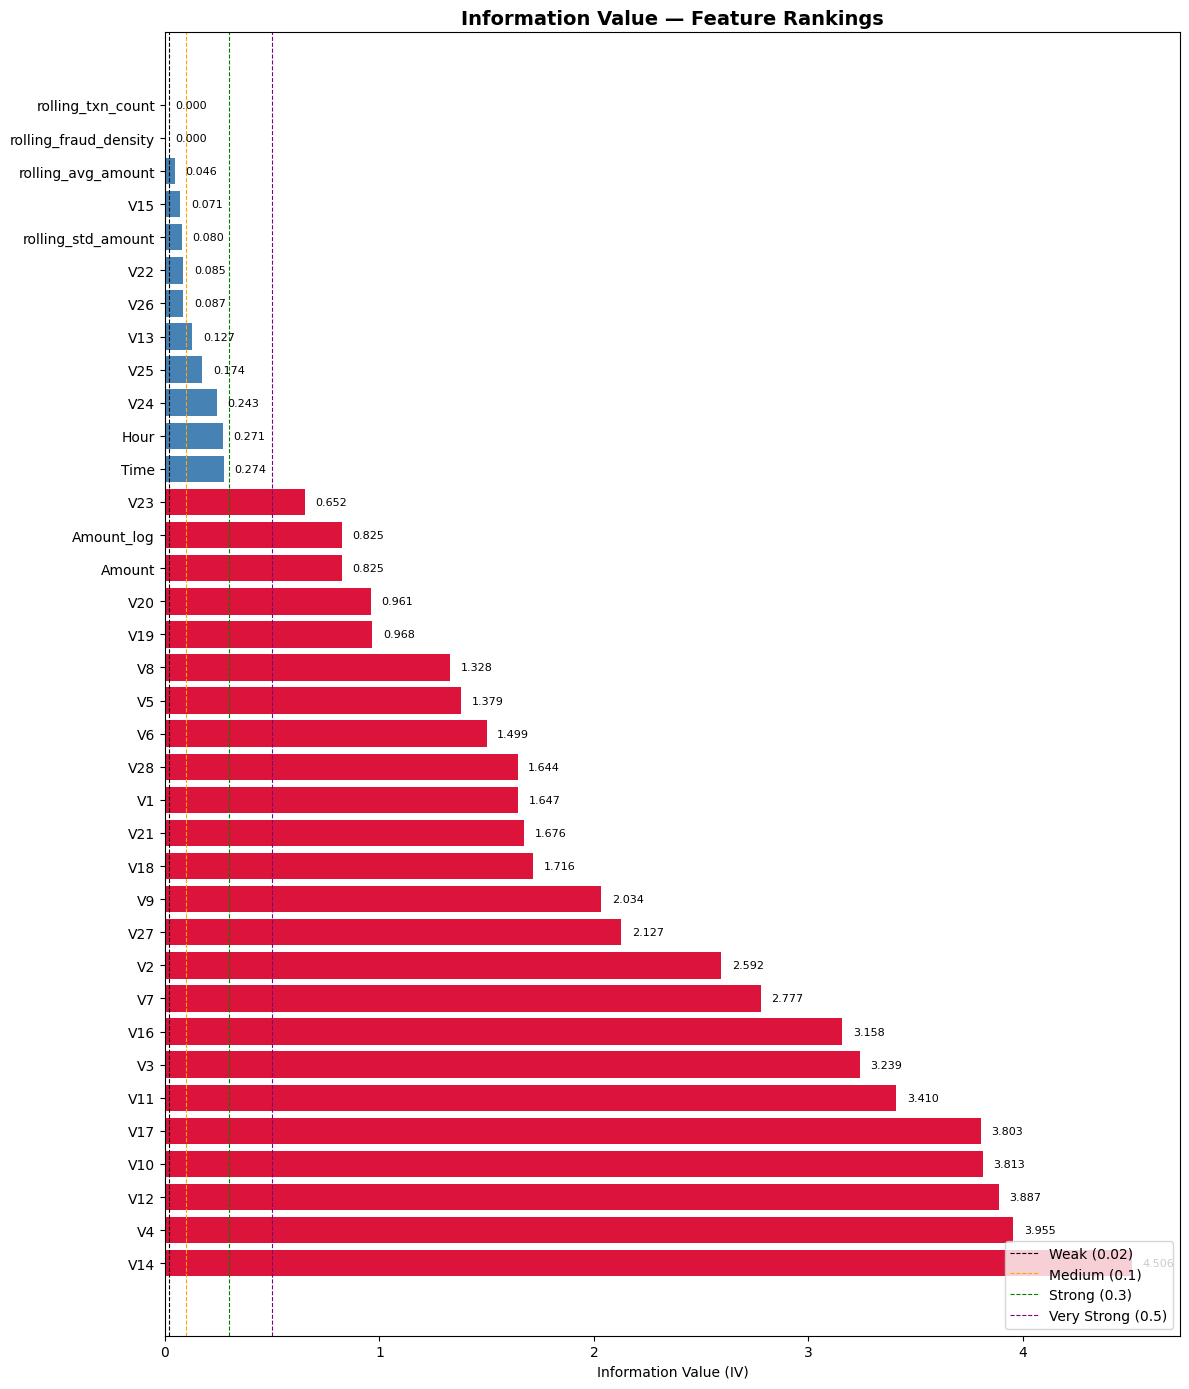

In [ ]:
# visualise IV rankings for all features
fig, ax = plt.subplots(figsize=(12, 14))

colors = ['crimson' if iv > 0.3 else 'steelblue' for iv in iv_df['IV']]
ax.barh(iv_df.index, iv_df['IV'], color=colors)

# IV threshold lines
ax.axvline(x=0.02, color='black', linestyle='--', linewidth=0.8, label='Weak (0.02)')
ax.axvline(x=0.1,  color='orange', linestyle='--', linewidth=0.8, label='Medium (0.1)')
ax.axvline(x=0.3,  color='green', linestyle='--', linewidth=0.8, label='Strong (0.3)')
ax.axvline(x=0.5,  color='purple', linestyle='--', linewidth=0.8, label='Very Strong (0.5)')

ax.set_title('Information Value — Feature Rankings', fontweight='bold', fontsize=14)
ax.set_xlabel('Information Value (IV)')
ax.legend(loc='lower right')



for i, (idx, row) in enumerate(iv_df.iterrows()):
    ax.text(row['IV'] + 0.05, i, f'{row["IV"]:.3f}', va='center', fontsize=8)


plt.tight_layout()
plt.show()